In [ ]:
# Mount Google Drive & Install Dependencies

from google.colab import drive
drive.mount('/content/drive')

!pip install groq pillow torch torchvision timm -q
print("All dependencies installed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All dependencies installed!


In [ ]:
# Configure Your API Key & Model Path

GROQ_API_KEY = "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"

MODEL_PATH   = "/content/drive/MyDrive/rice_disease_model.pth"  # path to your saved model

In [ ]:
# Load the Trained Model

import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Class names must match the training order (alphabetical via ImageFolder) ──
CLASS_NAMES = ['bacterial_leaf_blight', 'brown_spot', 'leaf_smut']

# ── Device ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ── Rebuild the exact same architecture used during training ──
model = models.efficientnet_b0(weights=None)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(model.classifier[1].in_features, len(CLASS_NAMES))
)

# ── Load saved weights ──
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully!")

# ── Preprocessing pipeline (same as val_transforms in training) ──
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

Using device: cuda
Model loaded successfully!


In [ ]:
# Val Transforms — must match training exactly

import torchvision.transforms as transforms

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [ ]:
!pip install "rembg[gpu]"

INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 111.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.3/270.3 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 136.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 139.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.8 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0

Please upload a rice leaf image...


Saving bacterial blight test2.jpg to bacterial blight test2 (2).jpg
Removing background and preprocessing... (may take ~10–20s)


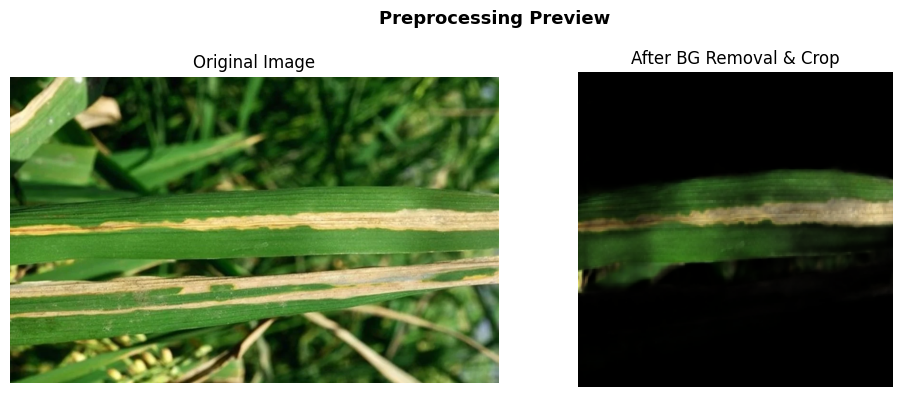

Predicted Disease : Bacterial Leaf Blight
Confidence        : 50.1%

  All class probabilities:
    bacterial_leaf_blight         50.1%  ███████████████
    brown_spot                    16.1%  ████
    leaf_smut                     33.8%  ██████████



In [ ]:
# Upload & Predict Disease from Image

from google.colab import files
from rembg import remove
from PIL import Image, ImageOps
import numpy as np
import io
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

#   FULL PREPROCESSING PIPELINE (matches training)

def preprocess_farmer_image(image_path):
    """
    Full preprocessing pipeline:
    1. Remove background
    2. Crop tightly around the leaf
    3. Resize to model input size
    """
    # Step 1: Load image
    img = Image.open(image_path).convert("RGBA")

    # Step 2: Remove background using rembg
    img_bytes = io.BytesIO()
    img.save(img_bytes, format="PNG")
    img_no_bg = remove(img_bytes.getvalue())
    img_no_bg = Image.open(io.BytesIO(img_no_bg)).convert("RGBA")

    # Step 3: Crop tightly around non-transparent pixels
    bbox = img_no_bg.getbbox()
    img_cropped = img_no_bg.crop(bbox) if bbox else img_no_bg

    # Step 4: Convert to RGB and resize
    img_rgb = img_cropped.convert("RGB")
    img_final = img_rgb.resize((224, 224))

    return img_final


#   UPLOAD IMAGE
print("Please upload a rice leaf image...")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# ── Show original ──
img_original = Image.open(image_path).convert("RGB")

print("Removing background and preprocessing... (may take ~10–20s)")
img_processed = preprocess_farmer_image(image_path)

# ── Show original vs processed side by side ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_original)
axes[0].set_title("Original Image", fontsize=12)
axes[0].axis('off')
axes[1].imshow(img_processed)
axes[1].set_title("After BG Removal & Crop", fontsize=12)
axes[1].axis('off')
plt.suptitle("Preprocessing Preview", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#   RUN INFERENCE
img_tensor = val_transforms(img_processed).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    outputs      = model(img_tensor)
    probabilities = F.softmax(outputs, dim=1)[0]

predicted_idx   = probabilities.argmax().item()
predicted_label = CLASS_NAMES[predicted_idx]
confidence      = probabilities[predicted_idx].item() * 100

#   DISPLAY RESULTS

print(f"Predicted Disease : {predicted_label.replace('_', ' ').title()}")
print(f"Confidence        : {confidence:.1f}%")

print("\n  All class probabilities:")
for name, prob in zip(CLASS_NAMES, probabilities):
    bar = '█' * int(prob.item() * 30)
    print(f"    {name:<28} {prob.item()*100:5.1f}%  {bar}")
print()

In [ ]:
# Heuristic-Based Fertilizer & Pesticide Lookup

DISEASE_KNOWLEDGE = {
    "bacterial_leaf_blight": {
        "display_name": "Bacterial Leaf Blight",
        "pathogen": "Xanthomonas oryzae pv. oryzae (Xoo)",
        "fertilizer": {
            "recommendation": "Reduce or avoid Nitrogen fertilizer during infection. Switch to balanced K-rich fertilizer.",
            "chemicals": [
                {"name": "Potassium Chloride (KCl)",        "dosage": "60 kg/ha",   "frequency": "Once at tillering stage"},
                {"name": "Diammonium Phosphate (DAP)",      "dosage": "50 kg/ha",   "frequency": "Basal application only — avoid top-dressing"}
            ],
            "note": "Excess nitrogen promotes bacterial spread. Maintain field drainage."
        },
        "pesticide": {
            "recommendation": "Use copper-based bactericides and streptomycin-based antibiotics.",
            "chemicals": [
                {"name": "Copper Oxychloride 50% WP",       "dosage": "2.5 g/L water", "frequency": "Spray every 10–14 days, 2–3 applications"},
                {"name": "Streptomycin Sulphate 90% SP",    "dosage": "0.5 g/L water", "frequency": "2 sprays, 7 days apart at early infection"},
                {"name": "Kasugamycin 3% SL",               "dosage": "2 mL/L water",  "frequency": "Spray at 10-day intervals, max 3 times"}
            ]
        }
    },

    "brown_spot": {
        "display_name": "Brown Spot",
        "pathogen": "Bipolaris oryzae (Helminthosporium oryzae)",
        "fertilizer": {
            "recommendation": "Correct silicon and potassium deficiencies. Apply manganese if soil tests show deficiency.",
            "chemicals": [
                {"name": "Urea (46% N)",                    "dosage": "40–60 kg/ha",  "frequency": "Split application: basal + tillering"},
                {"name": "Single Super Phosphate (SSP)",    "dosage": "30 kg/ha",    "frequency": "Basal application before transplanting"},
                {"name": "Potassium Sulphate (K2SO4)",      "dosage": "40 kg/ha",    "frequency": "Once at active tillering stage"},
                {"name": "Silicon Fertilizer (Silica gel)",  "dosage": "100–200 kg/ha","frequency": "Basal application, improves leaf resistance"}
            ],
            "note": "Brown spot thrives in nutrient-deficient soils. Soil testing strongly recommended."
        },
        "pesticide": {
            "recommendation": "Apply systemic fungicides at booting to heading stage for best results.",
            "chemicals": [
                {"name": "Mancozeb 75% WP",                 "dosage": "2.5 g/L water", "frequency": "Spray at 10-day intervals, 2–3 times"},
                {"name": "Tricyclazole 75% WP",             "dosage": "0.6 g/L water", "frequency": "1–2 sprays at early symptom appearance"},
                {"name": "Iprobenfos (IBP) 48% EC",         "dosage": "1.5 mL/L water","frequency": "Apply at booting stage, repeat after 14 days"}
            ]
        }
    },

    "leaf_smut": {
        "display_name": "Leaf Smut",
        "pathogen": "Entyloma oryzae",
        "fertilizer": {
            "recommendation": "Reduce nitrogen to moderate levels. Ensure adequate phosphorus and potassium balance.",
            "chemicals": [
                {"name": "NPK Fertilizer (10:26:26)",       "dosage": "50 kg/ha",    "frequency": "Basal application at transplanting"},
                {"name": "Potassium Chloride (KCl)",        "dosage": "40 kg/ha",    "frequency": "Top-dress at tillering stage"}
            ],
            "note": "Leaf smut is favored by high humidity. Avoid over-irrigation."
        },
        "pesticide": {
            "recommendation": "Fungicide seed treatment is most effective. Foliar sprays help reduce spread.",
            "chemicals": [
                {"name": "Propiconazole 25% EC",            "dosage": "1 mL/L water",  "frequency": "2 sprays, 14 days apart"},
                {"name": "Hexaconazole 5% SC",              "dosage": "2 mL/L water",  "frequency": "Spray at first sign of symptoms"},
                {"name": "Carbendazim 50% WP",              "dosage": "1 g/L water",   "frequency": "Seed treatment: 2 g/kg seed before sowing"}
            ]
        }
    }
}

print("Knowledge base loaded!")


def get_rule_based_recommendations(disease_key):
    """Returns a formatted string of rule-based recommendations."""
    info = DISEASE_KNOWLEDGE.get(disease_key, {})
    if not info:
        return "No rule-based data available for this disease."

    lines = []
    lines.append(f"\n{'═'*55}")
    lines.append(f"  🌿 FERTILIZER RECOMMENDATIONS — {info['display_name']}")
    lines.append(f"{'═'*55}")
    lines.append(f"  {info['fertilizer']['recommendation']}")
    lines.append(f"\n  {'Chemical':<35} {'Dosage':<18} Frequency")
    lines.append(f"  {'-'*90}")
    for chem in info['fertilizer']['chemicals']:
        lines.append(f"  {chem['name']:<35} {chem['dosage']:<18} {chem['frequency']}")
    lines.append(f"\n  ℹ️  Note: {info['fertilizer']['note']}")

    lines.append(f"\n{'═'*55}")
    lines.append(f"  🧪 PESTICIDE / INSECTICIDE RECOMMENDATIONS")
    lines.append(f"{'═'*55}")
    lines.append(f"  {info['pesticide']['recommendation']}")
    lines.append(f"\n  {'Chemical':<35} {'Dosage':<18} Frequency")
    lines.append(f"  {'-'*90}")
    for chem in info['pesticide']['chemicals']:
        lines.append(f"  {chem['name']:<35} {chem['dosage']:<18} {chem['frequency']}")

    lines.append(f"\n{'═'*55}")
    lines.append("  ⚠️  DISCLAIMER")
    lines.append(f"{'═'*55}")
    lines.append("  The above dosages are general guidelines for rice cultivation.")
    lines.append("  Actual requirements vary by soil type, growth stage, and region.")
    lines.append("  Please consult your LOCAL AGRICULTURE OFFICER or extension")
    lines.append("  service before applying any chemical treatment. Always follow")
    lines.append("  the label instructions and wear protective equipment.")
    lines.append(f"{'═'*55}")

    return "\n".join(lines)

Knowledge base loaded!


In [ ]:
# LLM-Powered Disease Explanation (via Groq — Free)

from groq import Groq

# ── Initialize Groq client ──
groq_client = Groq(api_key=GROQ_API_KEY)


def get_llm_disease_explanation(disease_label, confidence):
    """
    Calls Groq LLM to generate:
      - Disease description & causes
      - Early vs severe symptoms
      - Immediate actions & prevention tips
    """
    disease_name = disease_label.replace('_', ' ').title()
    info         = DISEASE_KNOWLEDGE.get(disease_label, {})
    pathogen     = info.get('pathogen', 'unknown pathogen')

    prompt = f"""You are an expert agricultural plant pathologist specializing in rice crop diseases.

A rice leaf image has been analyzed by an AI model and the following disease has been detected:

- Disease: {disease_name}
- Causative Agent: {pathogen}
- Model Confidence: {confidence:.1f}%
- Crop: Rice (Oryza sativa)

Please provide a comprehensive disease advisory report in simple words with the following sections:

## 1. DISEASE DESCRIPTION & CAUSES
- What is {disease_name}?
- What causes it (pathogen type, mode of infection)?
- What environmental and agronomic conditions favor its spread?

## 2. SYMPTOMS
### Early Symptoms
- Describe what the farmer would see in the early stages

### Severe Symptoms
- Describe what the crop looks like when severely affected
- Mention expected yield loss if untreated

## 3. IMMEDIATE ACTIONS
- What should the farmer do RIGHT NOW upon detecting this disease?
- Any cultural / mechanical controls (remove affected leaves, improve drainage, etc.)

## 4. PREVENTION TIPS
- Long-term prevention strategies
- Seed selection, field hygiene, crop rotation advice
- Water management tips specific to this disease

Keep the language clear, practical, and understandable for a rice farmer.
Be specific to rice cultivation in South/Southeast Asia.
Format your response with clear headings and bullet points."""

    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",  # Free model with large context
        messages=[
            {"role": "system", "content": "You are an expert agricultural plant pathologist. Provide accurate, practical disease advisory reports for rice farmers."},
            {"role": "user",   "content": prompt}
        ],
        temperature=0.3,   # Low temp = more factual, less hallucination
        max_tokens=1500
    )

    return response.choices[0].message.content


print("LLM client ready!")

LLM client ready!


In [ ]:
# Generate Full Advisory Report

print("\n" + "█"*60)
print("     🌾 RICE DISEASE ADVISORY REPORT")
print("█"*60)

# ─── Section 0: Prediction Summary ───────────────────────────
disease_display = predicted_label.replace('_', ' ').title()
pathogen_name   = DISEASE_KNOWLEDGE[predicted_label]['pathogen']

print(f"""
  🔬 Detected Disease  : {disease_display}
  🦠 Causative Agent   : {pathogen_name}
  📊 Confidence        : {confidence:.1f}%
""")

if confidence < 60:
    print("  ⚠️  Warning: Confidence is below 60%. Consider consulting an expert")
    print("      or uploading a clearer image for more reliable results.\n")

# ─── Section 1 & 2: LLM Advisory ─────────────────────────────
print("█"*60)
print("     🤖 AI-GENERATED DISEASE ADVISORY")
print("     Powered by Groq (Llama 3.3 70B)")
print("█"*60)
print("\n⏳ Generating advisory from LLM... please wait...\n")

try:
    llm_report = get_llm_disease_explanation(predicted_label, confidence)
    print(llm_report)
except Exception as e:
    print(f"❌ LLM call failed: {e}")
    print("   Please check your GROQ_API_KEY and internet connection.")

# ─── Section 3: Rule-Based Fertilizer & Pesticide ─────────────
print("\n" + "█"*60)
print("     📋 RULE-BASED FERTILIZER & PESTICIDE GUIDE")
print("█"*60)
rule_report = get_rule_based_recommendations(predicted_label)
print(rule_report)

print("\n" + "█"*60)
print("     ✅ END OF ADVISORY REPORT")
print("█"*60)


████████████████████████████████████████████████████████████
     🌾 RICE DISEASE ADVISORY REPORT
████████████████████████████████████████████████████████████

  🔬 Detected Disease  : Bacterial Leaf Blight
  🦠 Causative Agent   : Xanthomonas oryzae pv. oryzae (Xoo)
  📊 Confidence        : 50.1%

  ⚠️  Warning: Confidence is below 60%. Consider consulting an expert
      or uploading a clearer image for more reliable results.

████████████████████████████████████████████████████████████
     🤖 AI-GENERATED DISEASE ADVISORY
     Powered by Groq (Llama 3.3 70B)
████████████████████████████████████████████████████████████

⏳ Generating advisory from LLM... please wait...

## 1. DISEASE DESCRIPTION & CAUSES
Bacterial Leaf Blight (BLB) is a significant disease affecting rice crops worldwide, particularly in South and Southeast Asia. It is caused by the bacterium Xanthomonas oryzae pv. oryzae (Xoo). This pathogen infects rice plants through natural openings or wounds on the leaves, causing di

In [ ]:
# Note:

# To analyze another image, simply re-run Cell 6 and then Cell 9 again. No need to reload the model.